# LLM Planning Bench — Results Analysis

Analysis of the **60-cell** experimental matrix:

- **5 models**, 3 core + 2 extension:
  - **Core**: `llama8` (Llama-3.1-8B), `qwen25` (Qwen2.5-32B), `llama33` (Llama-3.3-70B, 4-bit) — different families and sizes.
  - **Extension**: `qwq32` (QwQ-32B, same base as qwen25 + reasoning post-training), `mistral24` (Mistral-Small-24B, third family at the 24B band).
- **6 domains**, simple → complex:
  - **Simple** (10 instances each): `basic_move`, `visit-all`, `satellite`.
  - **Complex** (20 instances each): `blocksworld`, `citycar`, `tetris`.
- **2 prompting conditions**: `baseline`, `cot`.
- Up to 4 iterations per instance with stop-on-success.

The experiment was rolled out in waves: simple problems first to validate the pipeline (and serve as a sanity-check baseline), then complex problems as the headline benchmark. The model slate was similarly grown: 3 core models for the proposal-aligned comparison (intra-family scale, cross-family), then 2 extension models to address the **reasoning-post-training ablation** (qwq32 vs qwen25, same base) and a **third-family cross-check** (mistral24).

Each major section emits a saved figure under `../report/figures/` and a CSV/LaTeX table under `../report/tables/` so the report can include them directly.

## 1. Setup

In [ ]:
import glob
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ---- paths ----
RESULTS_DIR = Path('../src/results-final')
FIG_DIR = Path('../report/figures')
TBL_DIR = Path('../report/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

# ---- canonical orderings (3 core models first, then 2 extension; simple domains then complex) ----
CORE_MODELS = ['llama8', 'qwen25', 'llama33']
EXTENSION_MODELS = ['qwq32', 'mistral24']
MODELS_ORDER = CORE_MODELS + EXTENSION_MODELS

MODEL_LABELS = {
    'llama8':    'Llama-3.1-8B',
    'qwen25':    'Qwen2.5-32B',
    'llama33':   'Llama-3.3-70B (4-bit)',
    'qwq32':     'QwQ-32B',
    'mistral24': 'Mistral-Small-24B',
}
MODEL_PARAMS = {'llama8': 8, 'qwen25': 32, 'qwq32': 32, 'mistral24': 24, 'llama33': 70}
MODEL_FAMILY = {'llama8': 'Meta', 'llama33': 'Meta', 'qwen25': 'Alibaba', 'qwq32': 'Alibaba', 'mistral24': 'Mistral'}

SIMPLE_DOMAINS = ['basic_move', 'visit-all', 'satellite']
COMPLEX_DOMAINS = ['blocksworld', 'citycar', 'tetris']
DOMAINS_ORDER = SIMPLE_DOMAINS + COMPLEX_DOMAINS
CONDS_ORDER = ['baseline', 'cot']

# ---- color palette ----
MODEL_COLORS = {
    'llama8':    '#9ecae1',
    'llama33':   '#08519c',
    'qwen25':    '#fdae6b',
    'qwq32':     '#a63603',
    'mistral24': '#74c476',
}
DOMAIN_COLORS = {
    # simple — greens (visit-all/basic_move/satellite are short-plan)
    'basic_move':  '#a1d99b',
    'visit-all':   '#74c476',
    'satellite':   '#31a354',
    # complex — warm tones
    'blocksworld': '#2c7fb8',
    'citycar':     '#d95f0e',
    'tetris':      '#9ecae1',
}

# ---- plotting style ----
sns.set_theme(style='whitegrid', context='notebook')
mpl.rcParams['figure.dpi']        = 110
mpl.rcParams['savefig.dpi']       = 300
mpl.rcParams['savefig.bbox']      = 'tight'
mpl.rcParams['savefig.format']    = 'pdf'
mpl.rcParams['font.size']         = 11
mpl.rcParams['axes.titlesize']    = 12
mpl.rcParams['axes.labelsize']    = 11
mpl.rcParams['legend.fontsize']   = 10
mpl.rcParams['xtick.labelsize']   = 10
mpl.rcParams['ytick.labelsize']   = 10

print('Setup complete.')
print(f'Models   ({len(MODELS_ORDER)}): {MODELS_ORDER}')
print(f'Domains  ({len(DOMAINS_ORDER)}): {DOMAINS_ORDER}')
print(f'Conds    ({len(CONDS_ORDER)}): {CONDS_ORDER}')
print(f'Expected cells: {len(MODELS_ORDER)*len(DOMAINS_ORDER)*len(CONDS_ORDER)}')

Setup complete.
Models   (5): ['llama8', 'qwen25', 'llama33', 'qwq32', 'mistral24']
Domains  (6): ['basic_move', 'visit-all', 'satellite', 'blocksworld', 'citycar', 'tetris']
Conds    (2): ['baseline', 'cot']
Expected cells: 60


## 2. Load all 30 cells into a pooled DataFrame

In [2]:
frames = []
for f in sorted(glob.glob(str(RESULTS_DIR / '**' / 'run_metrics.csv'), recursive=True)):
    parts = Path(f).parts
    model, domain, condition = parts[-4], parts[-3], parts[-2]
    df = pd.read_csv(f)
    df['model_dir'] = model
    df['domain_dir'] = domain
    df['condition_dir'] = condition
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
all_df['model'] = all_df['model_dir']
all_df['domain'] = all_df['domain_dir']
all_df['condition'] = all_df['condition_dir']
all_df = all_df.drop(columns=['model_dir', 'domain_dir', 'condition_dir', 'prompting_condition'], errors='ignore')

print(f'Loaded {len(frames)} cells, {len(all_df):,} total iteration-rows.')
print(f'Models:     {sorted(all_df["model"].unique())}')
print(f'Domains:    {sorted(all_df["domain"].unique())}')
print(f'Conditions: {sorted(all_df["condition"].unique())}')
all_df.head(3)

Loaded 60 cells, 2,560 total iteration-rows.
Models:     ['llama33', 'llama8', 'mistral24', 'qwen25', 'qwq32']
Domains:    ['basic_move', 'blocksworld', 'citycar', 'satellite', 'tetris', 'visit-all']
Conditions: ['baseline', 'cot']


,model,domain,instance,iteration,plan_text,plan_len,solves_problem,valid_action_percent,consecutive_valid_steps,logical_violations,wallclock_s,prompt_tokens,completion_tokens,condition
0,llama33,basic_move,instance-01,1,(move l1 l2)\n(move l2 l3)\n(move l3 l4),3,True,100.0,3,0,17.495,693,18,baseline
1,llama33,basic_move,instance-02,1,(move l1 l2)\n(move l2 l3)\n(move l3 l4)\n(mov...,4,True,100.0,4,0,4.770,703,24,baseline
2,llama33,basic_move,instance-03,1,(move l1 l4),1,True,100.0,1,0,1.954,702,6,baseline


### Per-instance "best" rollup

For each `(model, domain, condition, instance)` we compute:
- `solved` — whether *any* iteration produced a valid plan
- `first_valid_iter` — earliest iteration with `solves_problem=True`, else NaN
- `iters_used` — last iteration the model attempted (1–4)
- `max_vap` — maximum `valid_action_percent` across iterations (best partial score)
- `final_vap` — `valid_action_percent` at `iters_used`
- token totals

This is the analysis-ready table. Most plots aggregate from here.

In [3]:
def first_valid(group):
    valid = group[group['solves_problem'] == True]
    return float(valid['iteration'].min()) if not valid.empty else np.nan

fvi_series = (all_df.groupby(['model','domain','condition','instance'])
                    .apply(first_valid, include_groups=False)
                    .rename('first_valid_iter')
                    .reset_index())

agg = (all_df
       .groupby(['model', 'domain', 'condition', 'instance'], as_index=False)
       .agg(solved          = ('solves_problem', 'any'),
            iters_used      = ('iteration', 'max'),
            max_vap         = ('valid_action_percent', 'max'),
            mean_vap        = ('valid_action_percent', 'mean'),
            best_consec     = ('consecutive_valid_steps', 'max'),
            total_violations= ('logical_violations', 'sum'),
            total_wallclock = ('wallclock_s', 'sum'),
            total_completion= ('completion_tokens', 'sum'),
            max_completion  = ('completion_tokens', 'max'),
       ))
agg = agg.merge(fvi_series, on=['model','domain','condition','instance'], how='left')

# final iteration's vap (the iter that was actually written as the final plan)
final_iter = (all_df.sort_values(['model','domain','condition','instance','iteration'])
                    .groupby(['model','domain','condition','instance'], as_index=False)
                    .tail(1)[['model','domain','condition','instance','valid_action_percent']]
                    .rename(columns={'valid_action_percent':'final_vap'}))
agg = agg.merge(final_iter, on=['model','domain','condition','instance'], how='left')

print(f'Per-instance rollup: {len(agg)} rows  ({len(agg)/30:.1f} instances/cell on average)')
agg.head(5)

Per-instance rollup: 871 rows  (29.0 instances/cell on average)


,model,domain,condition,instance,solved,iters_used,max_vap,mean_vap,best_consec,total_violations,total_wallclock,total_completion,max_completion,first_valid_iter,final_vap
0,llama33,basic_move,baseline,instance-01,True,1,100.0,100.0,3,0,17.495,18,18,1.0,100.0
1,llama33,basic_move,baseline,instance-02,True,1,100.0,100.0,4,0,4.770,24,24,1.0,100.0
2,llama33,basic_move,baseline,instance-03,True,1,100.0,100.0,1,0,1.954,6,6,1.0,100.0
3,llama33,basic_move,baseline,instance-04,True,1,100.0,100.0,5,0,5.705,30,30,1.0,100.0
4,llama33,basic_move,baseline,instance-05,True,1,100.0,100.0,2,0,2.884,12,12,1.0,100.0


## 3. Headline cell-level summary

One row per `(model, domain, condition)` cell. **Watch the `n` column** — any cell with `n < 20` had instances dropped (TIMEOUT or job error).

In [5]:
cell_summary = (agg
    .groupby(['model','domain','condition'], as_index=False)
    .agg(n = ('instance', 'nunique'),
         solved = ('solved', 'sum'),
         success_rate = ('solved', 'mean'),
         mean_max_vap = ('max_vap', 'mean'),
         median_max_vap=('max_vap', 'median'),
         mean_iters = ('iters_used', 'mean'),
         mean_first_valid_iter = ('first_valid_iter','mean'),
         mean_completion_tokens = ('max_completion','mean'))
)
cell_summary['model'] = pd.Categorical(cell_summary['model'], categories=MODELS_ORDER,  ordered=True)
cell_summary['domain'] = pd.Categorical(cell_summary['domain'], categories=DOMAINS_ORDER, ordered=True)
cell_summary['condition'] = pd.Categorical(cell_summary['condition'], categories=CONDS_ORDER,   ordered=True)
cell_summary = cell_summary.sort_values(['model','domain','condition']).reset_index(drop=True)

cell_summary.to_csv(TBL_DIR / 'cell_summary_full.csv', index=False)

incomplete = cell_summary[cell_summary['n'] < 20]
if not incomplete.empty:
    print('WARNING: Cells with <20 instances completed (TIMEOUT or error):')
    print(incomplete[['model','domain','condition','n']].to_string(index=False))
    print()

cell_summary

    model      domain condition  n
   llama8  basic_move  baseline 10
   llama8  basic_move       cot 10
   llama8   visit-all  baseline 10
   llama8   visit-all       cot 10
   llama8   satellite  baseline 10
   llama8   satellite       cot 10
   qwen25  basic_move  baseline 10
   qwen25  basic_move       cot 10
   qwen25   visit-all  baseline 10
   qwen25   visit-all       cot 10
   qwen25   satellite  baseline 10
   qwen25   satellite       cot 10
  llama33  basic_move  baseline 10
  llama33  basic_move       cot 10
  llama33   visit-all  baseline 10
  llama33   visit-all       cot 10
  llama33   satellite  baseline 10
  llama33   satellite       cot 10
    qwq32  basic_move  baseline 10
    qwq32  basic_move       cot 10
    qwq32   visit-all  baseline 10
    qwq32   visit-all       cot 10
    qwq32   satellite  baseline 10
    qwq32   satellite       cot 10
    qwq32 blocksworld  baseline 19
    qwq32     citycar  baseline 15
    qwq32     citycar       cot 17
    qwq32      tetri

,model,domain,condition,n,solved,success_rate,mean_max_vap,median_max_vap,mean_iters,mean_first_valid_iter,mean_completion_tokens
0,llama8,basic_move,baseline,10,9,0.900000,96.250000,100.000000,1.300000,1.000000,74.600000
1,llama8,basic_move,cot,10,10,1.000000,100.000000,100.000000,1.100000,1.100000,286.700000
2,llama8,visit-all,baseline,10,7,0.700000,84.738562,100.000000,2.100000,1.285714,192.900000
3,llama8,visit-all,cot,10,7,0.700000,84.464286,100.000000,2.000000,1.142857,383.400000
4,llama8,satellite,baseline,10,0,0.000000,51.567479,46.606335,3.500000,NaN,387.200000
5,llama8,satellite,cot,10,0,0.000000,32.607143,29.285714,3.100000,NaN,669.600000
6,llama8,blocksworld,baseline,20,0,0.000000,17.966954,9.166667,4.000000,NaN,850.900000
7,llama8,blocksworld,cot,20,0,0.000000,30.850154,25.000000,4.000000,NaN,2023.250000
8,llama8,citycar,baseline,20,0,0.000000,9.066957,5.256410,3.500000,NaN,2898.500000
9,llama8,citycar,cot,20,0,0.000000,17.439824,6.666667,3.700000,NaN,4125.100000


## 4. Plot 1 — Solves heatmap (model × cell)

Color = number of instances **fully solved** (out of 20). This is the headline success-rate matrix.

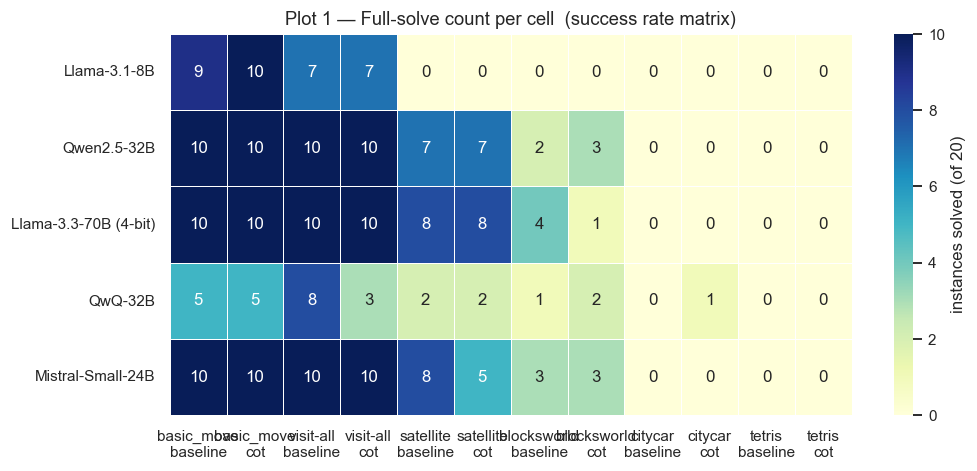

In [6]:
def heatmap_pivot(df, value_col):
    pv = df.pivot_table(index='model', columns=['domain','condition'],
                        values=value_col, observed=True)
    pv = pv.reindex(MODELS_ORDER)
    cols = [(d, c) for d in DOMAINS_ORDER for c in CONDS_ORDER]
    pv = pv[cols]
    return pv

solves_pv = heatmap_pivot(cell_summary, 'solved')

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(solves_pv, annot=True, fmt='.0f', cmap='YlGnBu',
            vmin=0, vmax=max(1, solves_pv.values.max()),
            cbar_kws={'label': 'instances solved (of 20)'},
            linewidths=0.5, ax=ax)
ax.set_yticklabels([MODEL_LABELS[m] for m in solves_pv.index], rotation=0)
ax.set_xticklabels([f'{d}\n{c}' for d, c in solves_pv.columns], rotation=0)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Plot 1 — Full-solve count per cell  (success rate matrix)')
plt.savefig(FIG_DIR / 'plot1_solves_heatmap.pdf')
plt.show()

## 5. Plot 2 — Mean partial-validity heatmap

Mean of per-instance `max valid_action_%`. Most plans never fully solve; this shows how *close* each cell got — the granular signal that distinguishes models even when nobody hits 100%.

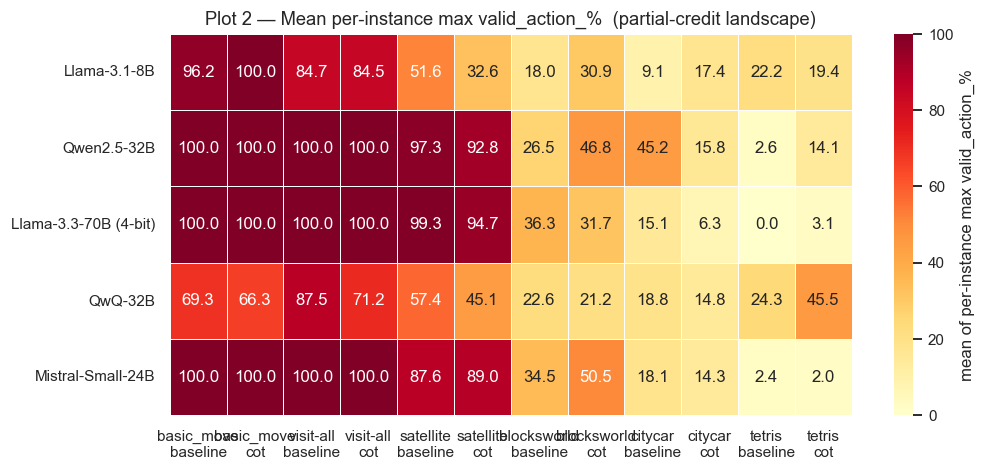

In [7]:
vap_pv = heatmap_pivot(cell_summary, 'mean_max_vap')

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(vap_pv, annot=True, fmt='.1f', cmap='YlOrRd',
            vmin=0, vmax=max(40, vap_pv.values.max()),
            cbar_kws={'label': 'mean of per-instance max valid_action_%'},
            linewidths=0.5, ax=ax)
ax.set_yticklabels([MODEL_LABELS[m] for m in vap_pv.index], rotation=0)
ax.set_xticklabels([f'{d}\n{c}' for d, c in vap_pv.columns], rotation=0)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Plot 2 — Mean per-instance max valid_action_%  (partial-credit landscape)')
plt.savefig(FIG_DIR / 'plot2_vap_heatmap.pdf')
plt.show()

## 6. Plot 3 — Iteration-gain curves

For each cell, the cumulative fraction of instances solved at iteration ≤ k.  
Lines that climb across iters mean the **VAL feedback loop is helping**; flat lines mean the model produces its best plan first and never recovers.

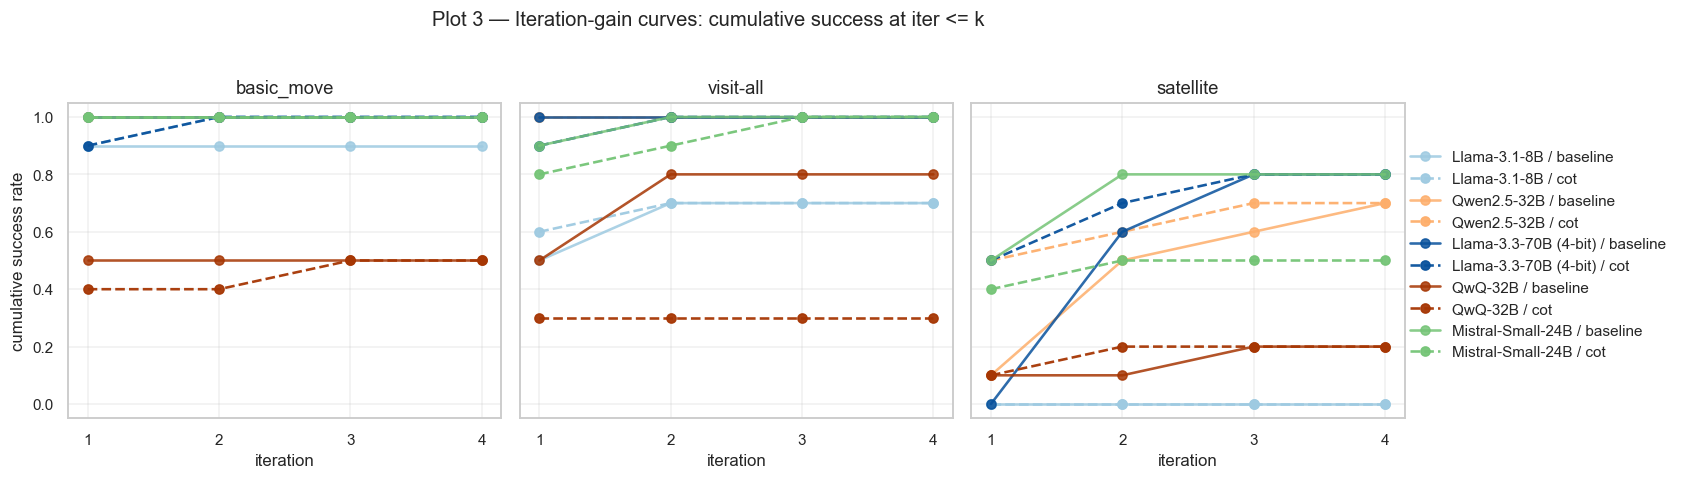

In [8]:
def cumulative_solve_curve(df_cell):
    n_inst = df_cell['instance'].nunique()
    if n_inst == 0:
        return [np.nan]*4
    cum = []
    for k in range(1, 5):
        solved_by_k = df_cell.loc[df_cell['first_valid_iter'].fillna(99) <= k, 'instance'].nunique()
        cum.append(solved_by_k / n_inst)
    return cum

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, dom in zip(axes, DOMAINS_ORDER):
    for m in MODELS_ORDER:
        for c, ls in zip(CONDS_ORDER, ['-', '--']):
            cell = agg.query('model == @m and domain == @dom and condition == @c')
            curve = cumulative_solve_curve(cell)
            ax.plot(range(1, 5), curve,
                    color=MODEL_COLORS[m], linestyle=ls, marker='o',
                    label=f'{MODEL_LABELS[m]} / {c}', linewidth=1.7,
                    alpha=0.95 if c=='cot' else 0.85)
    ax.set_xlabel('iteration')
    ax.set_xticks([1, 2, 3, 4])
    ax.set_title(dom)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('cumulative success rate')
h, l = axes[-1].get_legend_handles_labels()
fig.legend(h, l, loc='center right', bbox_to_anchor=(1.18, 0.5), frameon=False, ncol=1)
fig.suptitle('Plot 3 — Iteration-gain curves: cumulative success at iter <= k', y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot3_iteration_gain.pdf')
plt.show()

## 7. Plot 4 — CoT delta (headline finding)

For each `(model, domain)`, plot `mean_max_vap[cot] - mean_max_vap[baseline]`.  
Positive bar = CoT helps. Negative bar = CoT hurts.

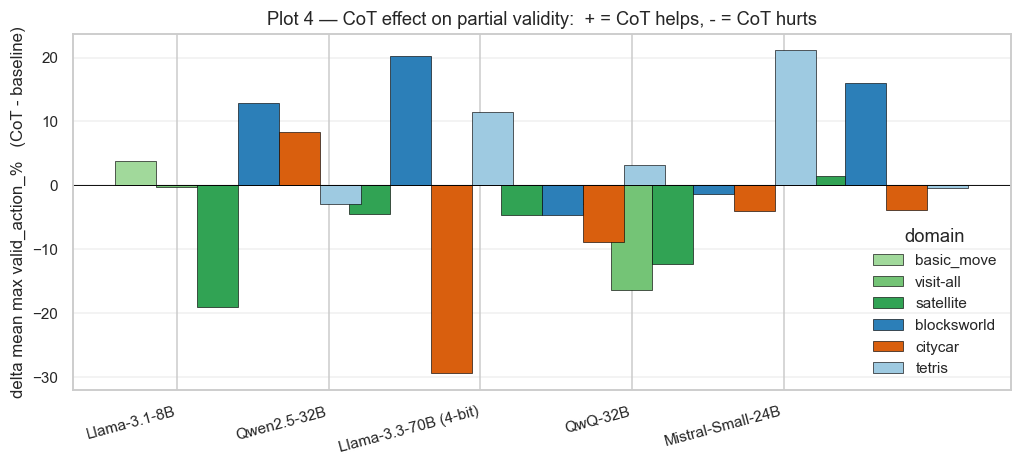

CoT delta table (delta vap, percentage points):
    model      domain  baseline    cot  delta
   llama8  basic_move     96.25 100.00   3.75
   llama8   visit-all     84.74  84.46  -0.27
   llama8   satellite     51.57  32.61 -18.96
   llama8 blocksworld     17.97  30.85  12.88
   llama8     citycar      9.07  17.44   8.37
   llama8      tetris     22.21  19.37  -2.84
   qwen25  basic_move    100.00 100.00   0.00
   qwen25   visit-all    100.00 100.00   0.00
   qwen25   satellite     97.33  92.79  -4.54
   qwen25 blocksworld     26.49  46.77  20.28
   qwen25     citycar     45.25  15.81 -29.44
   qwen25      tetris      2.62  14.08  11.45
  llama33  basic_move    100.00 100.00   0.00
  llama33   visit-all    100.00 100.00   0.00
  llama33   satellite     99.33  94.74  -4.60
  llama33 blocksworld     36.34  31.69  -4.66
  llama33     citycar     15.13   6.31  -8.82
  llama33      tetris      0.00   3.12   3.12
    qwq32  basic_move     69.31  66.35  -2.96
    qwq32   visit-all     87.50 

In [ ]:
vap_wide = (cell_summary
            .pivot_table(index=['model','domain'], columns='condition', values='mean_max_vap', observed=True)
            .reset_index())
vap_wide['delta'] = vap_wide['cot'] - vap_wide['baseline']
vap_wide['model'] = pd.Categorical(vap_wide['model'],  categories=MODELS_ORDER,  ordered=True)
vap_wide['domain'] = pd.Categorical(vap_wide['domain'], categories=DOMAINS_ORDER, ordered=True)
vap_wide = vap_wide.sort_values(['model','domain']).reset_index(drop=True)
vap_wide.to_csv(TBL_DIR / 'cot_delta_vap.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 4.2))
x = np.arange(len(MODELS_ORDER))
width = 0.27
for i, dom in enumerate(DOMAINS_ORDER):
    rows = vap_wide[vap_wide['domain'] == dom].sort_values('model')
    deltas = []
    for m in MODELS_ORDER:
        sub = rows[rows['model']==m]
        deltas.append(sub['delta'].iloc[0] if not sub.empty else np.nan)
    ax.bar(x + (i-1)*width, deltas, width=width,
           color=DOMAIN_COLORS[dom], label=dom, edgecolor='black', linewidth=0.4)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS_ORDER], rotation=15, ha='right')
ax.set_ylabel('delta mean max valid_action_%   (CoT - baseline)')
ax.set_title('Plot 4 — CoT effect on partial validity:  + = CoT helps, - = CoT hurts')
ax.legend(title='domain', frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.savefig(FIG_DIR / 'plot4_cot_delta.pdf')
plt.show()

print('CoT delta table (delta vap, percentage points):')
print(vap_wide[['model','domain','baseline','cot','delta']].round(2).to_string(index=False))

## 8. Plot 5 — Intra-family scaling (Llama 8B vs 70B)

Llama-3.1-8B and Llama-3.3-70B share family-level inductive biases. Difference between them is mostly capacity (and the 4-bit quantization on 70B — flagged in the limitations section).

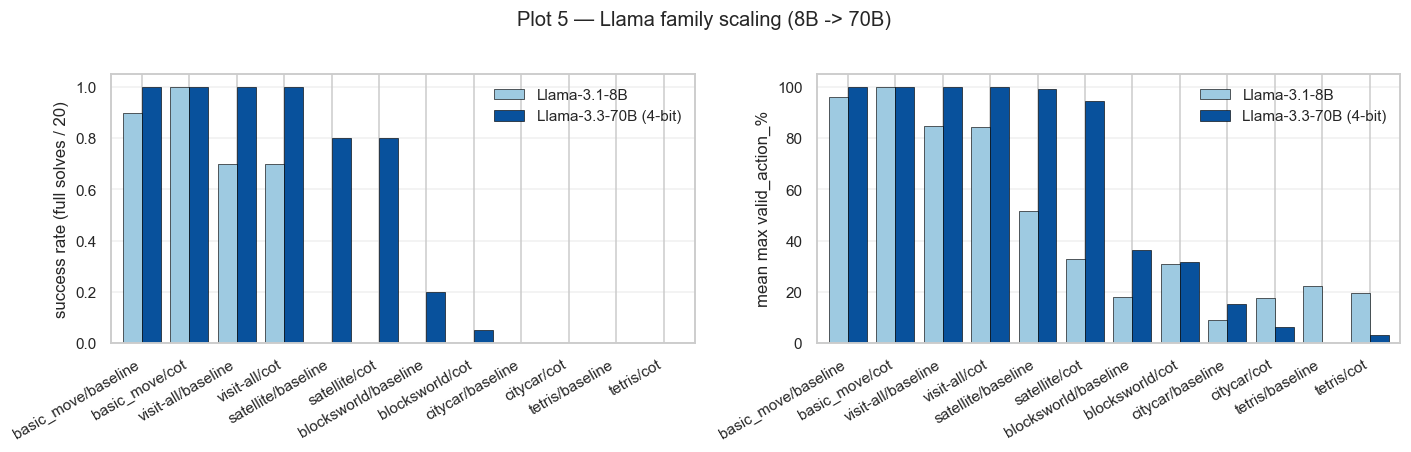

In [10]:
llama_pair = cell_summary[cell_summary['model'].isin(['llama8','llama33'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, ylabel in [
    (axes[0], 'success_rate', 'success rate (full solves / 20)'),
    (axes[1], 'mean_max_vap',  'mean max valid_action_%'),
]:
    pv = llama_pair.pivot_table(index=['domain','condition'],
                                 columns='model', values=metric, observed=True)
    pv = pv.reindex([(d,c) for d in DOMAINS_ORDER for c in CONDS_ORDER])
    pv = pv[['llama8','llama33']]
    pv.plot(kind='bar', ax=ax,
            color=[MODEL_COLORS['llama8'], MODEL_COLORS['llama33']],
            edgecolor='black', linewidth=0.4, width=0.8)
    ax.set_xticklabels([f'{d}/{c}' for d, c in pv.index], rotation=30, ha='right')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.legend([MODEL_LABELS['llama8'], MODEL_LABELS['llama33']], frameon=False)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Plot 5 — Llama family scaling (8B -> 70B)', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot5_llama_scaling.pdf')
plt.show()

## 9. Plot 6 — Cross-family at the 24-32B parameter band

Three models in the same size band but from different families:
- **mistral24** (Mistral-Small-24B) — Mistral
- **qwen25** (Qwen2.5-32B) — Alibaba, base instruct model
- **qwq32** (QwQ-32B) — Alibaba, same base + reasoning post-training

Differences here isolate **family / training** effects from the size confound.

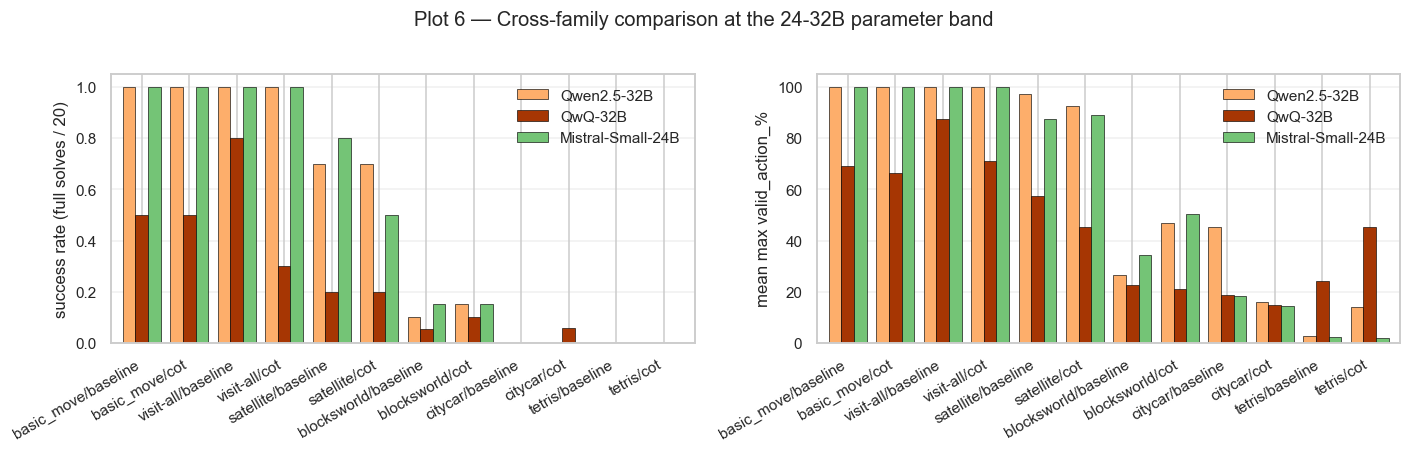

In [11]:
band = cell_summary[cell_summary['model'].isin(['mistral24','qwen25','qwq32'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, ylabel in [
    (axes[0], 'success_rate', 'success rate (full solves / 20)'),
    (axes[1], 'mean_max_vap',  'mean max valid_action_%'),
]:
    pv = band.pivot_table(index=['domain','condition'], columns='model', values=metric, observed=True)
    pv = pv.reindex([(d,c) for d in DOMAINS_ORDER for c in CONDS_ORDER])
    pv = pv[['qwen25','qwq32','mistral24']]
    pv.plot(kind='bar', ax=ax,
            color=[MODEL_COLORS['qwen25'], MODEL_COLORS['qwq32'], MODEL_COLORS['mistral24']],
            edgecolor='black', linewidth=0.4, width=0.8)
    ax.set_xticklabels([f'{d}/{c}' for d, c in pv.index], rotation=30, ha='right')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.legend([MODEL_LABELS[m] for m in ['qwen25','qwq32','mistral24']], frameon=False)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Plot 6 — Cross-family comparison at the 24-32B parameter band', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot6_cross_family.pdf')
plt.show()

## 10. Plot 7 — Reasoning-post-training ablation: QwQ-32B vs Qwen2.5-32B

**Same architecture, same parameter count, same base model.** The only difference is whether the model went through reasoning fine-tuning. Δ = `qwq32 − qwen25` per cell.

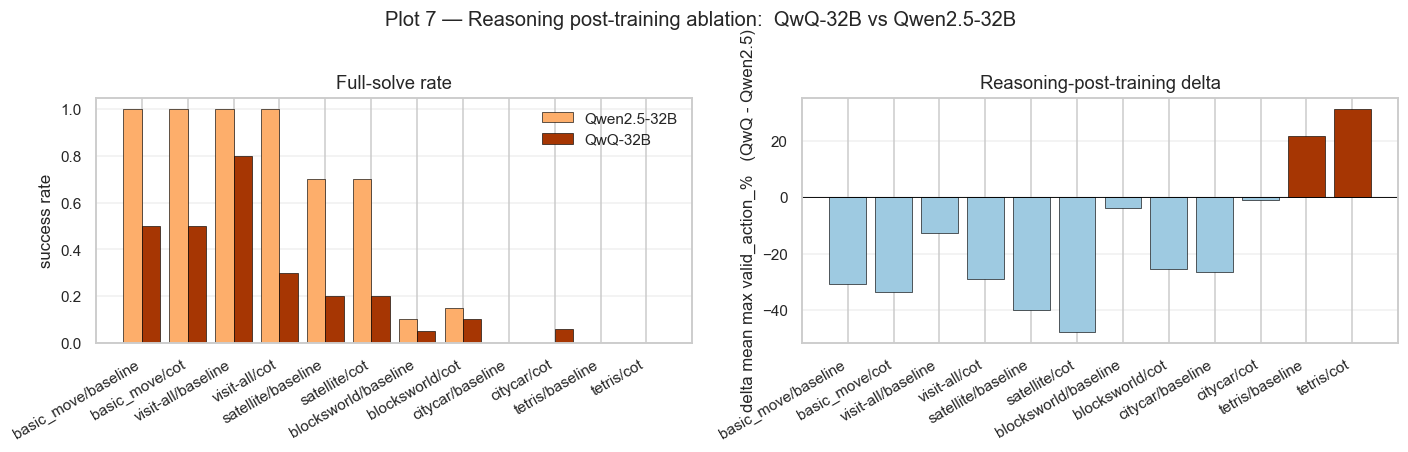


QwQ vs Qwen2.5-32B per-cell delta (positive = QwQ wins):
                          Dsuccess         Dvap
model                 qwq32-qwen25 qwq32-qwen25
domain      condition                          
basic_move  baseline        -0.500      -30.694
            cot             -0.500      -33.655
visit-all   baseline        -0.200      -12.500
            cot             -0.700      -28.824
satellite   baseline        -0.500      -39.897
            cot             -0.500      -47.657
blocksworld baseline        -0.047       -3.920
            cot             -0.050      -25.532
citycar     baseline         0.000      -26.468
            cot              0.059       -0.979
tetris      baseline         0.000       21.649
            cot              0.000       31.377


In [12]:
qwen_pair = cell_summary[cell_summary['model'].isin(['qwen25','qwq32'])].copy()
qwen_wide = qwen_pair.pivot_table(index=['domain','condition'],
                                   columns='model',
                                   values=['success_rate','mean_max_vap'], observed=True)
qwen_wide = qwen_wide.reindex([(d,c) for d in DOMAINS_ORDER for c in CONDS_ORDER])

qwen_wide[('Dsuccess','qwq32-qwen25')] = qwen_wide[('success_rate','qwq32')] - qwen_wide[('success_rate','qwen25')]
qwen_wide[('Dvap', 'qwq32-qwen25')] = qwen_wide[('mean_max_vap','qwq32')] - qwen_wide[('mean_max_vap','qwen25')]
qwen_wide.to_csv(TBL_DIR / 'qwq_vs_qwen_ablation.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels = [f'{d}/{c}' for d, c in qwen_wide.index]
x = np.arange(len(labels))

ax = axes[0]
ax.bar(x - 0.2, qwen_wide[('success_rate','qwen25')], width=0.4,
       color=MODEL_COLORS['qwen25'], label='Qwen2.5-32B', edgecolor='black', linewidth=0.4)
ax.bar(x + 0.2, qwen_wide[('success_rate','qwq32')], width=0.4,
       color=MODEL_COLORS['qwq32'],  label='QwQ-32B',    edgecolor='black', linewidth=0.4)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('success rate')
ax.set_title('Full-solve rate')
ax.legend(frameon=False); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
deltas = qwen_wide[('Dvap','qwq32-qwen25')].values
colors = ['#a63603' if d>=0 else '#9ecae1' for d in deltas]
ax.bar(x, deltas, color=colors, edgecolor='black', linewidth=0.4)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('delta mean max valid_action_%   (QwQ - Qwen2.5)')
ax.set_title('Reasoning-post-training delta')
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Plot 7 — Reasoning post-training ablation:  QwQ-32B vs Qwen2.5-32B', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot7_qwq_ablation.pdf')
plt.show()

print()
print('QwQ vs Qwen2.5-32B per-cell delta (positive = QwQ wins):')
print(qwen_wide[[('Dsuccess','qwq32-qwen25'), ('Dvap','qwq32-qwen25')]].round(3).to_string())

## 11. Plot 8 — First-valid-iteration distribution

For *solved* instances per cell: how often did the model nail it on iteration 1, 2, 3, or 4?  
If most successes are at iter 1, the iterative-feedback loop isn't doing much work.

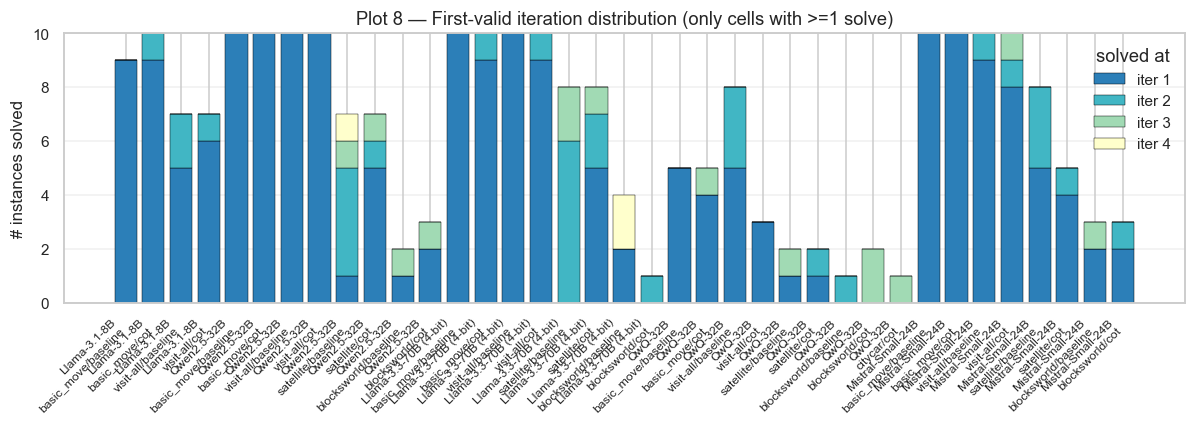

In [16]:
fvi = (agg.dropna(subset=['first_valid_iter'])
          .groupby(['model','domain','condition','first_valid_iter'], observed=True)
          .size()
          .reset_index(name='count'))
fvi['model']  = pd.Categorical(fvi['model'], categories=MODELS_ORDER, ordered=True)
fvi['domain'] = pd.Categorical(fvi['domain'], categories=DOMAINS_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(11, 4))
cells_with_solves = (cell_summary[cell_summary['solved']>0]
                     .sort_values(['model','domain','condition'])
                     .reset_index(drop=True))
if cells_with_solves.empty:
    ax.text(0.5, 0.5, 'No cells with full solves', ha='center', va='center')
else:
    iter_colors = ['#2c7fb8','#41b6c4','#a1dab4','#ffffcc']
    bottoms = np.zeros(len(cells_with_solves))
    cell_keys = list(zip(cells_with_solves['model'], cells_with_solves['domain'], cells_with_solves['condition']))
    x = np.arange(len(cell_keys))
    for k_int in [1, 2, 3, 4]:
        k = float(k_int)
        counts = []
        for (m,d,c) in cell_keys:
            sel = fvi.query('model==@m and domain==@d and condition==@c and first_valid_iter==@k')
            counts.append(sel['count'].sum() if not sel.empty else 0)
        ax.bar(x, counts, bottom=bottoms,
               color=iter_colors[k_int-1],
               edgecolor='black', linewidth=0.3,
               label=f'iter {k_int}')
        bottoms = bottoms + np.array(counts)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{MODEL_LABELS[m]}\n{d}/{c}' for m,d,c in cell_keys],
                       rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('# instances solved')
    ax.set_title('Plot 8 — First-valid iteration distribution (only cells with >=1 solve)')
    ax.legend(title='solved at', frameon=False)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot8_first_valid_iter.pdf')
plt.show()

## 12. Plot 9 — Partial-credit distribution on never-solved instances

For each cell, show the per-instance distribution of best `valid_action_%` among instances that **never fully solved**. Tells you whether failures are "close calls" or "miles off".

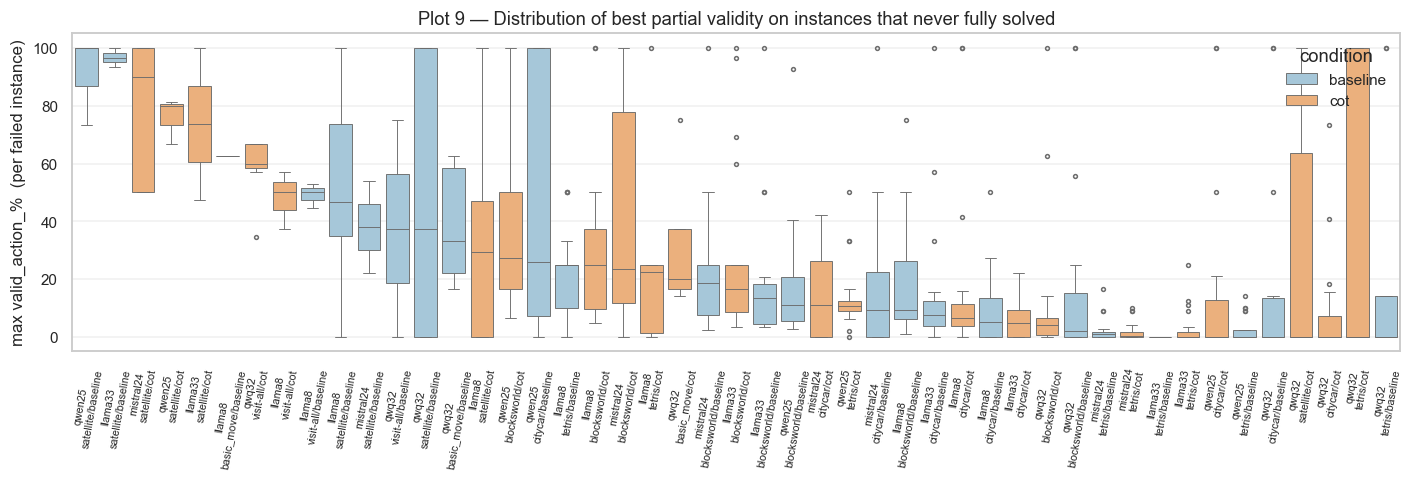

In [17]:
fail_only = agg[agg['solved'] == False].copy()
fail_only['model']  = pd.Categorical(fail_only['model'],  categories=MODELS_ORDER, ordered=True)
fail_only['domain'] = pd.Categorical(fail_only['domain'], categories=DOMAINS_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(13, 4.5))
fail_only['cell'] = (fail_only['model'].astype(str) + '\n' +
                     fail_only['domain'].astype(str) + '/' +
                     fail_only['condition'].astype(str))
order = (fail_only.groupby('cell', observed=True)['max_vap']
         .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=fail_only, x='cell', y='max_vap', order=order,
            hue='condition', dodge=False,
            palette={'baseline':'#9ecae1','cot':'#fdae6b'},
            ax=ax, fliersize=2.5, linewidth=0.6)
ax.set_xlabel('')
ax.set_ylabel('max valid_action_%  (per failed instance)')
ax.set_title('Plot 9 — Distribution of best partial validity on instances that never fully solved')
ax.tick_params(axis='x', rotation=80, labelsize=7)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='condition', frameon=False, loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot9_partial_credit_box.pdf')
plt.show()

## 13. Plot 10 — Domain difficulty ranking

Aggregating across all models and conditions: which domain is hardest? Both axes (success rate, partial validity).

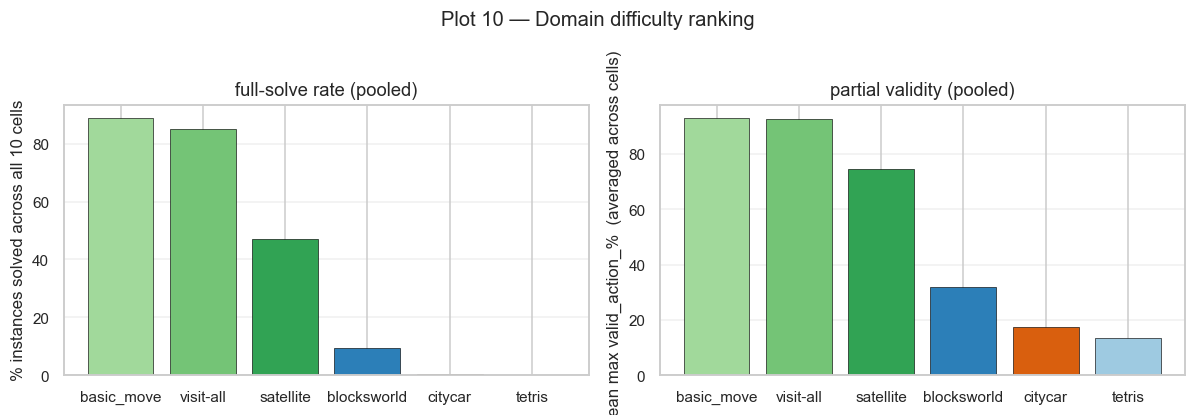


     domain  mean_success_rate  mean_max_vap  total_solved  total_n  solve_pct
 basic_move               0.89         93.19            89      100      89.00
  visit-all               0.85         92.79            85      100      85.00
  satellite               0.47         74.75            47      100      47.00
blocksworld               0.10         31.89            19      199       9.55
    citycar               0.01         17.50             1      192       0.52
     tetris               0.00         13.55             0      180       0.00


In [18]:
by_domain = (cell_summary
             .groupby('domain', as_index=False, observed=True)
             .agg(mean_success_rate=('success_rate','mean'),
                  mean_max_vap=('mean_max_vap','mean'),
                  total_solved=('solved','sum'),
                  total_n=('n','sum')))
by_domain['solve_pct'] = 100 * by_domain['total_solved'] / by_domain['total_n']
by_domain = by_domain.sort_values('mean_max_vap', ascending=False)
by_domain.to_csv(TBL_DIR / 'domain_difficulty.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(by_domain['domain'].astype(str), by_domain['solve_pct'],
            color=[DOMAIN_COLORS[d] for d in by_domain['domain']], edgecolor='black', linewidth=0.4)
axes[0].set_ylabel('% instances solved across all 10 cells')
axes[0].set_title('full-solve rate (pooled)')
axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(by_domain['domain'].astype(str), by_domain['mean_max_vap'],
            color=[DOMAIN_COLORS[d] for d in by_domain['domain']], edgecolor='black', linewidth=0.4)
axes[1].set_ylabel('mean max valid_action_%  (averaged across cells)')
axes[1].set_title('partial validity (pooled)')
axes[1].grid(axis='y', alpha=0.3)
fig.suptitle('Plot 10 — Domain difficulty ranking', y=1.04)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot10_domain_difficulty.pdf')
plt.show()

print()
print(by_domain.round(2).to_string(index=False))

## 14. Plot 11 — Token-budget diagnostics

Per-model distribution of `completion_tokens` (the actual length of model output).  
Spikes pegged at the cap (8192 / 16384) reveal **truncation** behavior — typically a small model rambling.  
Note: waves 1–2 (llama8 / qwen25 / llama33) used `max_new_tokens=8192`; wave 3 (qwq32 / mistral24) used `16384`. Flagged in the limitations section.

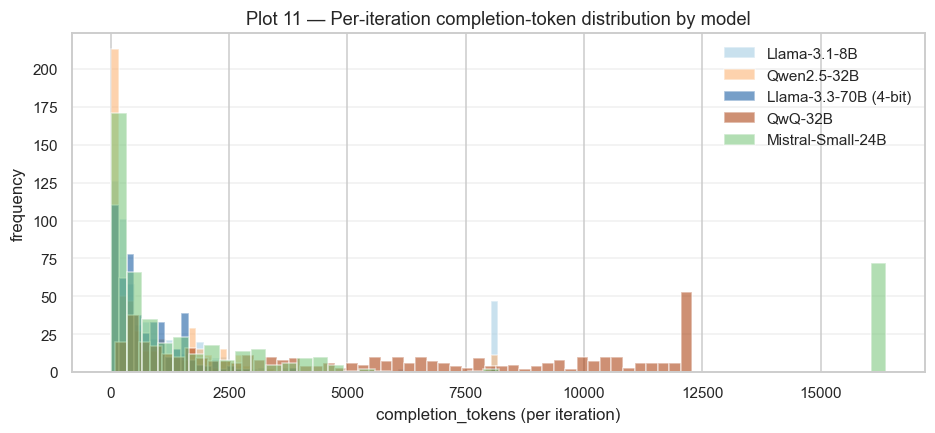

Per-model completion_tokens summary:


,mean,median,max,pct_at_or_near_8k_cap
model,,,,
llama8,1464.90,530.0,8192,0.08
qwen25,886.33,338.0,8192,0.02
llama33,819.42,483.0,8192,0.01
qwq32,5630.91,5185.0,12288,0.33
mistral24,3408.58,774.0,16384,0.15


In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
for m in MODELS_ORDER:
    vals = all_df[all_df['model']==m]['completion_tokens']
    ax.hist(vals, bins=50, alpha=0.55, label=MODEL_LABELS[m], color=MODEL_COLORS[m])
ax.set_xlabel('completion_tokens (per iteration)')
ax.set_ylabel('frequency')
ax.set_title('Plot 11 — Per-iteration completion-token distribution by model')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.savefig(FIG_DIR / 'plot11_token_distribution.pdf')
plt.show()

print('Per-model completion_tokens summary:')
tok_summary = (all_df.groupby('model', observed=True)['completion_tokens']
               .agg(['mean','median','max', lambda s: (s>=8000).mean()]))
tok_summary.columns = ['mean','median','max','pct_at_or_near_8k_cap']
tok_summary = tok_summary.reindex(MODELS_ORDER).round(2)
tok_summary.to_csv(TBL_DIR / 'token_distribution.csv')
tok_summary

## 15. Tables for the report

Generate clean, report-ready tables

In [20]:
table_a = (cell_summary[['model','domain','condition','n','solved','success_rate','mean_max_vap','median_max_vap','mean_first_valid_iter']]
           .copy())
table_a['success_rate'] = (table_a['success_rate']*100).round(1)
table_a['mean_max_vap']  = table_a['mean_max_vap'].round(1)
table_a['median_max_vap'] = table_a['median_max_vap'].round(1)
table_a['mean_first_valid_iter'] = table_a['mean_first_valid_iter'].round(2)
table_a.columns = ['model','domain','condition','n','solved','success_pct','mean_max_vap_pct','median_max_vap_pct','mean_first_valid_iter']
_table_a_tex = table_a.rename(columns={'success_pct':'success \%','mean_max_vap_pct':'mean max vap \%','median_max_vap_pct':'median max vap \%','mean_first_valid_iter':'mean 1st-valid iter'})
table_a.to_csv(TBL_DIR / 'table_a_headline_30cells.csv', index=False)
with open(TBL_DIR / 'table_a_headline_30cells.tex', 'w', encoding='utf-8') as f:
    f.write(_table_a_tex.to_latex(index=False, na_rep='--', float_format='%.1f', escape=True))
print('Wrote table_a_headline_30cells.csv + .tex')
table_a

Wrote table_a_headline_30cells.csv + .tex


,model,domain,condition,n,solved,success_pct,mean_max_vap_pct,median_max_vap_pct,mean_first_valid_iter
0,llama8,basic_move,baseline,10,9,90.0,96.2,100.0,1.00
1,llama8,basic_move,cot,10,10,100.0,100.0,100.0,1.10
2,llama8,visit-all,baseline,10,7,70.0,84.7,100.0,1.29
3,llama8,visit-all,cot,10,7,70.0,84.5,100.0,1.14
4,llama8,satellite,baseline,10,0,0.0,51.6,46.6,NaN
5,llama8,satellite,cot,10,0,0.0,32.6,29.3,NaN
6,llama8,blocksworld,baseline,20,0,0.0,18.0,9.2,NaN
7,llama8,blocksworld,cot,20,0,0.0,30.9,25.0,NaN
8,llama8,citycar,baseline,20,0,0.0,9.1,5.3,NaN
9,llama8,citycar,cot,20,0,0.0,17.4,6.7,NaN


In [ ]:
# ---- Table B: 18-cell core matrix (headline deliverable) ----
core_models = ['llama8','qwen25','llama33']
table_b = table_a[table_a['model'].isin(core_models)].copy()
_table_b_tex = _table_a_tex[_table_a_tex['model'].isin(core_models)].copy()
table_b.to_csv(TBL_DIR / 'table_b_core_18cells.csv', index=False)
with open(TBL_DIR / 'table_b_core_18cells.tex','w', encoding='utf-8') as f:
    f.write(_table_b_tex.to_latex(index=False, na_rep='--', float_format='%.1f', escape=True))
print('Wrote table_b_core_18cells.csv + .tex')
table_b

In [ ]:
# ---- Table C: CoT-effect summary (delta vap per (model, domain)) ----
table_c = vap_wide[['model','domain','baseline','cot','delta']].copy()
for col in ['baseline','cot','delta']:
    table_c[col] = table_c[col].round(2)
table_c.columns = ['model','domain','baseline_vap_pct','cot_vap_pct','delta_pp']
_table_c_tex = table_c.rename(columns={'baseline_vap_pct':'baseline vap \%','cot_vap_pct':'cot vap \%','delta_pp':'$\Delta$ pp'})
table_c.to_csv(TBL_DIR / 'table_c_cot_effect.csv', index=False)
with open(TBL_DIR / 'table_c_cot_effect.tex','w', encoding='utf-8') as f:
    f.write(_table_c_tex.to_latex(index=False, na_rep='--', float_format='%.2f', escape=True))
print('Wrote table_c_cot_effect.csv + .tex')
table_c

In [ ]:
# ---- Table D: QwQ ablation summary (per cell delta) ----
table_d = qwen_wide.copy()
table_d.columns = ['_'.join(c).strip('_') for c in table_d.columns]
table_d = table_d.reset_index()
table_d.to_csv(TBL_DIR / 'table_d_qwq_ablation.csv', index=False)
_table_d_tex = table_d.rename(columns={c: c.replace('_', ' ').replace('-', ' minus ') for c in table_d.columns})
with open(TBL_DIR / 'table_d_qwq_ablation.tex','w', encoding='utf-8') as f:
    f.write(_table_d_tex.round(3).to_latex(index=False, na_rep='--', float_format='%.3f', escape=True))
print('Wrote table_d_qwq_ablation.csv + .tex')
table_d

In [ ]:
# ---- Table E: family-level summary ----
fam_df = cell_summary.copy()
fam_df['family'] = fam_df['model'].map(MODEL_FAMILY)
table_e = (fam_df.groupby('family', observed=True)
          .agg(n_cells=('n','count'),
               total_n=('n','sum'),
               total_solved=('solved','sum'),
               mean_success_rate=('success_rate','mean'),
               mean_max_vap=('mean_max_vap','mean'))
          .round(3)
          .reset_index())
table_e['solve_pct'] = (100*table_e['total_solved']/table_e['total_n']).round(2)
table_e.to_csv(TBL_DIR / 'table_e_family_summary.csv', index=False)
with open(TBL_DIR / 'table_e_family_summary.tex','w', encoding='utf-8') as f:
    f.write(table_e.rename(columns={c: c.replace('_',' ') for c in table_e.columns}).to_latex(index=False, na_rep='--', float_format='%.3f', escape=True))
print('Wrote table_e_family_summary.csv + .tex')
table_e

## 16. Per-instance difficulty (ground-truth + LLM consensus)

We have **two views of difficulty**:
1. **Ground-truth optimal plan length** — from `pyperplan` (BFS / A*+hff) for `blocksworld`, `basic_move`, `visit-all` and from a hand-curated reference for `satellite` (pyperplan can't parse `:equality`). `citycar` and `tetris` use `:functions` (numeric fluents) which pyperplan also can't parse — those domains have no ground-truth column.
2. **Empirical instance difficulty** — fraction of (model, condition) cells that ever solved each instance. Universal across all 5 models * 2 conditions = up to 10 attempts per instance.

In [21]:
DATA_DIR = Path('../src/data')

ref_frames = []
for d in DOMAINS_ORDER:
    p = DATA_DIR / d / 'REFERENCE_PLANS.csv'
    if not p.exists():
        continue
    rdf = pd.read_csv(p)
    rdf['domain'] = d
    ref_frames.append(rdf)

if ref_frames:
    ref_df = pd.concat(ref_frames, ignore_index=True)
    ref_df = ref_df[ref_df['plan_len'] > 0].copy()
    print(f'Loaded reference plans for {ref_df["domain"].nunique()} domains, {len(ref_df)} instances total')
    summary = ref_df.groupby('domain', as_index=False).agg(
        n=('plan_len','count'),
        min_plan=('plan_len','min'),
        max_plan=('plan_len','max'),
        mean_plan=('plan_len','mean'),
    ).round(2)
    print(summary.to_string(index=False))
else:
    ref_df = pd.DataFrame(columns=['instance','plan_len','status','domain'])
    print('No REFERENCE_PLANS.csv files found - skipping ground-truth plots')

Loaded reference plans for 4 domains, 50 instances total
     domain  n  min_plan  max_plan  mean_plan
 basic_move 10         1         7        4.2
blocksworld 20         4        26       14.4
  satellite 10         5        18        9.8
  visit-all 10         2        10        5.4


### Plot 12 - Per-domain reference plan-length distribution

Boxplot of optimal plan lengths per domain. Quick visual of which domains require longer plans (a coarse difficulty signal).

C:\Users\Hassan\AppData\Local\Temp\ipykernel_14104\668550117.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ref_df, x='domain', y='plan_len', order=ordered,


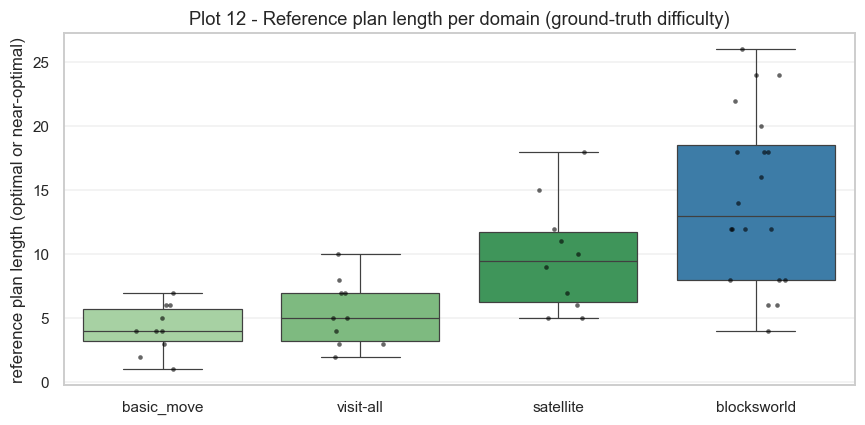

In [22]:
if not ref_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ordered = (ref_df.groupby('domain')['plan_len'].mean()
                     .sort_values().index.tolist())
    sns.boxplot(data=ref_df, x='domain', y='plan_len', order=ordered,
                palette={d: DOMAIN_COLORS.get(d, '#888888') for d in ordered},
                ax=ax, fliersize=3, linewidth=0.8)
    sns.stripplot(data=ref_df, x='domain', y='plan_len', order=ordered,
                  color='black', size=3, jitter=0.15, ax=ax, alpha=0.6)
    ax.set_ylabel('reference plan length (optimal or near-optimal)')
    ax.set_xlabel('')
    ax.set_title('Plot 12 - Reference plan length per domain (ground-truth difficulty)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'plot12_reference_plan_length.pdf')
    plt.show()
else:
    print('No reference plans available - Plot 12 skipped.')

### Plot 13 - Per-instance reference difficulty within each domain

Within each domain that has reference plans, plot the optimal plan length per instance, sorted ascending. The shape of the curve tells you whether the instance set has a smooth difficulty gradient or sharp jumps.

In [ ]:
if not ref_df.empty:
    domains_with_ref = sorted(ref_df['domain'].unique(),
                              key=lambda d: ref_df[ref_df['domain']==d]['plan_len'].mean())
    fig, axes = plt.subplots(1, len(domains_with_ref),
                              figsize=(3.5*len(domains_with_ref), 3.5), sharey=False)
    if len(domains_with_ref) == 1: axes = [axes]
    for ax, dom in zip(axes, domains_with_ref):
        sub = ref_df[ref_df['domain']==dom].copy().sort_values('plan_len').reset_index(drop=True)
        ax.bar(np.arange(len(sub)), sub['plan_len'],
               color=DOMAIN_COLORS.get(dom, '#666666'), edgecolor='black', linewidth=0.4)
        for i, (_, r) in enumerate(sub.iterrows()):
            ax.text(i, r['plan_len'], f' {r["instance"][-2:]}',
                    ha='center', va='bottom', fontsize=7, rotation=0)
        ax.set_title(f'{dom}  (n={len(sub)}, mean={sub["plan_len"].mean():.1f})')
        ax.set_xticks([])
        ax.set_ylabel('plan_len' if dom == domains_with_ref[0] else '')
        ax.set_xlabel('instances (sorted easy -> hard)')
        ax.grid(axis='y', alpha=0.3)
    plt.suptitle('Plot 13 - Per-instance reference difficulty', y=1.04)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'plot13_instance_difficulty.pdf')
    plt.show()
else:
    print('No reference plans available - Plot 13 skipped.')

### Plot 14 - Empirical per-instance difficulty (model consensus)

For each (domain, instance), what fraction of the (model, condition) cells solved it?  
Universal-easy = all 10 cells solved it.  Universal-hard = nobody solved it.  
This view doesn't depend on a planner being able to parse the domain - it works for citycar / tetris too.

In [ ]:
consensus = (agg
    .groupby(['domain','instance'], as_index=False)
    .agg(n_cells=('solved','count'),
         n_solved=('solved','sum'),
         mean_max_vap=('max_vap','mean')))
consensus['solve_rate'] = consensus['n_solved'] / consensus['n_cells']
consensus['domain'] = pd.Categorical(consensus['domain'],
    categories=sorted(consensus['domain'].unique()), ordered=True)

consensus.to_csv(TBL_DIR / 'instance_consensus_difficulty.csv', index=False)

domains_sorted = sorted(consensus['domain'].unique())
n_dom = len(domains_sorted)
ncols = 3
nrows = (n_dom + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5*nrows), sharey=True)
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
for ax, dom in zip(axes, domains_sorted):
    sub = consensus[consensus['domain']==dom].sort_values('mean_max_vap').reset_index(drop=True)
    color = DOMAIN_COLORS.get(dom, '#888888')
    ax.bar(np.arange(len(sub)), sub['mean_max_vap'], color=color, edgecolor='black', linewidth=0.3)
    ax2 = ax.twinx()
    ax2.plot(np.arange(len(sub)), sub['solve_rate']*100, color='red', marker='o', markersize=3, linewidth=1.0)
    ax2.set_ylim(-5, 105)
    ax2.set_ylabel('% cells solving (red)')
    ax.set_xticks(np.arange(len(sub)))
    ax.set_xticklabels([s.replace('instance-','i') for s in sub['instance']], rotation=60, fontsize=7)
    ax.set_title(f'{dom}  (n={len(sub)} instances)')
    ax.set_ylabel('mean max valid_action_%')
    ax.grid(axis='y', alpha=0.3)
for ax in axes[len(domains_sorted):]:
    ax.axis('off')
plt.suptitle('Plot 14 - Per-instance consensus difficulty (sorted easy -> hard within domain)', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'plot14_instance_consensus.pdf')
plt.show()

### Plot 15 - Reference difficulty vs model performance

Scatter of (optimal plan length) vs (mean partial validity across all 10 cells), with one point per (domain, instance). Negative slope confirms harder reference plans are also harder for the models. Domains with no reference plans (citycar, tetris) are excluded.

In [ ]:
if not ref_df.empty:
    merged = consensus.merge(ref_df[['domain','instance','plan_len']],
                              on=['domain','instance'], how='inner')
    if not merged.empty:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for dom in merged['domain'].unique():
            sub = merged[merged['domain']==dom]
            ax.scatter(sub['plan_len'], sub['mean_max_vap'],
                       color=DOMAIN_COLORS.get(dom, '#666'), edgecolor='black', s=60,
                       label=dom, alpha=0.85)
        if len(merged) >= 3:
            xs = merged['plan_len'].values.astype(float)
            ys = merged['mean_max_vap'].values.astype(float)
            slope, intercept = np.polyfit(xs, ys, 1)
            corr = np.corrcoef(xs, ys)[0, 1]
            xline = np.array([xs.min(), xs.max()])
            ax.plot(xline, slope*xline + intercept, color='black', linestyle='--', linewidth=1.0,
                    label=f'slope={slope:.2f} pp/step,  r={corr:.2f}')
        ax.set_xlabel('reference (optimal-or-near-optimal) plan length')
        ax.set_ylabel('mean max valid_action_% across 10 cells')
        ax.set_title('Plot 15 - Reference difficulty vs empirical model performance')
        ax.legend(frameon=False, fontsize=9)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'plot15_difficulty_vs_performance.pdf')
        plt.show()
    else:
        print('No instances with both reference plan and run metrics - Plot 15 skipped.')
else:
    print('No reference plans available - Plot 15 skipped.')

### Hardest and easiest instances per domain (consensus)

Useful as a callout in the report - 'instance X was the hardest in domain Y'.

In [ ]:
rows = []
for dom in sorted(consensus['domain'].unique()):
    sub = consensus[consensus['domain']==dom]
    easiest = sub.nlargest(1, 'mean_max_vap').iloc[0]
    hardest = sub.nsmallest(1, 'mean_max_vap').iloc[0]
    rows.append({
        'domain': dom,
        'easiest_instance': easiest['instance'],
        'easiest_solved_by': f"{int(easiest['n_solved'])}/{int(easiest['n_cells'])}",
        'easiest_vap': round(easiest['mean_max_vap'], 1),
        'hardest_instance': hardest['instance'],
        'hardest_solved_by': f"{int(hardest['n_solved'])}/{int(hardest['n_cells'])}",
        'hardest_vap': round(hardest['mean_max_vap'], 1),
    })
extremes = pd.DataFrame(rows)
extremes.to_csv(TBL_DIR / 'instance_extremes.csv', index=False)
extremes

## 17. Limitations & methodological caveats

Recorded as a CSV for direct inclusion in the report's Limitations section.

In [ ]:
limitations = [
    ('Stop-on-success bias',
     'Iter 2-4 metrics only contain instances that failed at iter 1. Per-iteration aggregates therefore appear to *worsen* across iterations because the easy instances drop out. The cumulative-solve curves (Plot 3) avoid this by using the per-instance first-valid-iter as the x-axis instead.'),
    ('Llama-3.3-70B in 4-bit',
     '70B was loaded with NF4 quantization (bitsandbytes) to fit on 2x A100-64GB. The other four models ran in bf16. Quantization noise can cost a few percentage points; treat 70B numbers as a lower bound.'),
    ('Wave 3 used max_new_tokens=16384',
     'qwq32 and mistral24 were submitted with a 16384-token output cap; llama8 / qwen25 / llama33 used 8192. Wave 3 was bumped because QwQ\'s reasoning traces fill ~3-6k tokens before any plan tokens. Cells from waves 1-2 hitting 8192 (notably llama8 in 99% of iters) may have lost late-plan content.'),
    ('QwQ TIMEOUT cells',
     'QwQ\'s long <think>...</think> traces eat the 10h walltime on harder domains. Some qwq32 cells have <20 instances completed; aggregates over these cells are not strictly comparable to fully-completed cells.'),
    ('CUDA non-determinism',
     'torch.use_deterministic_algorithms was not enabled. Re-running an identical cell can produce slightly different outputs even with seed=42, due to non-deterministic CUDA kernels and multi-GPU collective ordering.'),
    ('Sampling at T=0.1',
     'do_sample=True with T=0.1 is narrow but not greedy. Combined with the partial CUDA non-determinism, single-run numbers carry ~1-3 pp noise.'),
    ('20 instances per cell',
     'Small-N. Differences smaller than ~5 percentage points between cells should not be over-interpreted. Bootstrap CIs would be a useful follow-up.'),
    ('Domain difficulty is not equalized',
     'Blocksworld has 4 actions and short plans (~10 steps); CityCar and Tetris have richer state and longer optimal plans. Difficulty is partially confounded with state-space size.'),
]

lim_df = pd.DataFrame(limitations, columns=['caveat','description'])
lim_df.to_csv(TBL_DIR / 'limitations.csv', index=False)
for cav, desc in limitations:
    print(f'• {cav}\n  {desc}\n')

## 18. Final TL;DR — what's in the data

Run this cell last; it prints the headline findings text-only so you can paste straight into a results section.

In [23]:
print('=== HEADLINE FINDINGS ===\n')

total_solves = int(cell_summary['solved'].sum())
total_attempts = int(cell_summary['n'].sum())
print(f'1. Total full solves: {total_solves} / {total_attempts} ({100*total_solves/total_attempts:.1f}%)')

best = cell_summary.nlargest(3, 'mean_max_vap')
worst = cell_summary.nsmallest(3, 'mean_max_vap')
print('\n2. Best 3 cells (by mean max vap):')
for _, r in best.iterrows():
    print(f'   {MODEL_LABELS[r["model"]]} / {r["domain"]} / {r["condition"]}  ->  {r["mean_max_vap"]:.1f}%  ({int(r["solved"])}/{int(r["n"])} solved)')
print('\n   Worst 3 cells (by mean max vap):')
for _, r in worst.iterrows():
    print(f'   {MODEL_LABELS[r["model"]]} / {r["domain"]} / {r["condition"]}  ->  {r["mean_max_vap"]:.1f}%  ({int(r["solved"])}/{int(r["n"])} solved)')

n_helps = int((vap_wide['delta'] > 1).sum())
n_hurts = int((vap_wide['delta'] < -1).sum())
n_neutral = int((vap_wide['delta'].abs() <= 1).sum())
print(f'\n3. CoT effect across (model, domain) pairs (delta vap, threshold +/- 1pp):')
print(f'   helps:    {n_helps}/{len(vap_wide)}')
print(f'   hurts:    {n_hurts}/{len(vap_wide)}')
print(f'   neutral:  {n_neutral}/{len(vap_wide)}')

qwq_d = qwen_wide[('Dvap','qwq32-qwen25')].dropna()
wins = int((qwq_d > 1).sum())
losses = int((qwq_d < -1).sum())
ties = int((qwq_d.abs() <= 1).sum())
print(f'\n4. QwQ-32B vs Qwen2.5-32B (reasoning post-training delta vap):')
print(f'   QwQ wins:  {wins}/{len(qwq_d)} cells')
print(f'   QwQ loses: {losses}/{len(qwq_d)} cells')
print(f'   ties:      {ties}/{len(qwq_d)} cells')
print(f'   pooled delta vap: {qwq_d.mean():+.2f} percentage points')

print(f'\n5. Domain difficulty (easiest -> hardest, by pooled mean max vap):')
for _, r in by_domain.iterrows():
    print(f'   {str(r["domain"]):<12}  vap={r["mean_max_vap"]:.1f}%   solve_pct={r["solve_pct"]:.1f}%')

scale_8b = cell_summary[cell_summary['model']=='llama8' ]['mean_max_vap'].mean()
scale_70b = cell_summary[cell_summary['model']=='llama33']['mean_max_vap'].mean()
print(f'\n6. Llama family scaling (mean across 6 cells):')
print(f'   Llama-3.1-8B   -> {scale_8b:.2f}%  vap')
print(f'   Llama-3.3-70B  -> {scale_70b:.2f}%  vap   (4-bit, lower bound)')
print(f'   delta          -> {scale_70b - scale_8b:+.2f} pp')

print('\n=== END ===')
print(f'\nAll figures saved under: {FIG_DIR.resolve()}')
print(f'All tables  saved under: {TBL_DIR.resolve()}')

=== HEADLINE FINDINGS ===

1. Total full solves: 241 / 871 (27.7%)

2. Best 3 cells (by mean max vap):
   Llama-3.1-8B / basic_move / cot  ->  100.0%  (10/10 solved)
   Qwen2.5-32B / basic_move / baseline  ->  100.0%  (10/10 solved)
   Qwen2.5-32B / basic_move / cot  ->  100.0%  (10/10 solved)

   Worst 3 cells (by mean max vap):
   Llama-3.3-70B (4-bit) / tetris / baseline  ->  0.0%  (0/20 solved)
   Mistral-Small-24B / tetris / cot  ->  2.0%  (0/20 solved)
   Mistral-Small-24B / tetris / baseline  ->  2.4%  (0/20 solved)

3. CoT effect across (model, domain) pairs (delta vap, threshold +/- 1pp):
   helps:    9/30
   hurts:    13/30
   neutral:  8/30

4. QwQ-32B vs Qwen2.5-32B (reasoning post-training delta vap):
   QwQ wins:  2/12 cells
   QwQ loses: 9/12 cells
   ties:      1/12 cells
   pooled delta vap: -16.43 percentage points

5. Domain difficulty (easiest -> hardest, by pooled mean max vap):
   basic_move    vap=93.2%   solve_pct=89.0%
   visit-all     vap=92.8%   solve_pct=85.